**Βήμα 1ο**: Ανάγνωση δεδομένων

In [1]:
# Εισαγωγή της βιβλιοθήκης Pandas
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Εργασίες/1η εργασία - Classification/Dataset2Use_Assignment1.xlsx'

# Διάβασμα του αρχείου και αποθήκευση στη μεταβλητή 'df'
try:
    df = pd.read_excel(file_path)
    print("Το αρχείο διαβάστηκε.")

    # Εμφάνιση των 5 πρώτων γραμμών
    print("\n--- Οι πρώτες 5 γραμμές των δεδομένων ---")
    print(df.head())

    # Εμφάνιση του μεγέθους του πίνακα (γραμμές, στήλες)
    print("\n--- Διαστάσεις του πίνακα ---")
    print(f"Γραμμές (Εταιρείες): {df.shape[0]}")
    print(f"Στήλες (Χαρακτηριστικά): {df.shape[1]}")

except FileNotFoundError:
    print("Σφάλμα: Το αρχείο δεν βρέθηκε.")

Mounted at /content/drive
Το αρχείο διαβάστηκε.

--- Οι πρώτες 5 γραμμές των δεδομένων ---
   365* ( Β.Υ / Κοστ.Πωλ )  Λειτ.Αποτ/Συν.Ενεργ. (ROA)  \
0              1014.128862                    0.011751   
1               561.974631                    0.099662   
2               826.919025                    0.009594   
3               493.176956                    0.196284   
4               100.421465                    0.179038   

   ΧΡΗΜ.ΔΑΠΑΝΕΣ / ΠΩΛΗΣΕΙΣ   ΠΡΑΓΜΑΤΙΚΗ ΡΕΥΣΤΟΤΗΤΑ :  (ΚΕ-ΑΠΟΘΕΜΑΤΑ) / Β.Υ  \
0                 0.038505                                        0.965479   
1                 0.015775                                        1.415467   
2                 0.093562                                        1.575034   
3                 0.000581                                        1.346780   
4                 0.000173                                        3.299687   

   (ΑΠΑΙΤ.*365) / ΠΩΛ.  Συν.Υποχρ/Συν.Ενεργ  Διάρκεια Παραμονής Αποθεμάτων  \
0           5

**Βήμα 2ο**: Εκτύπωση γραφημάτων

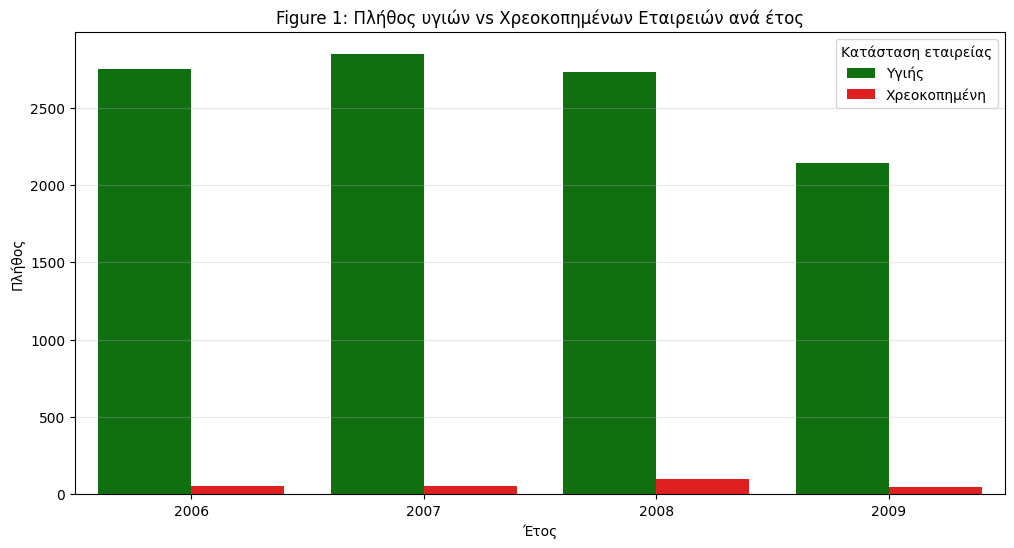

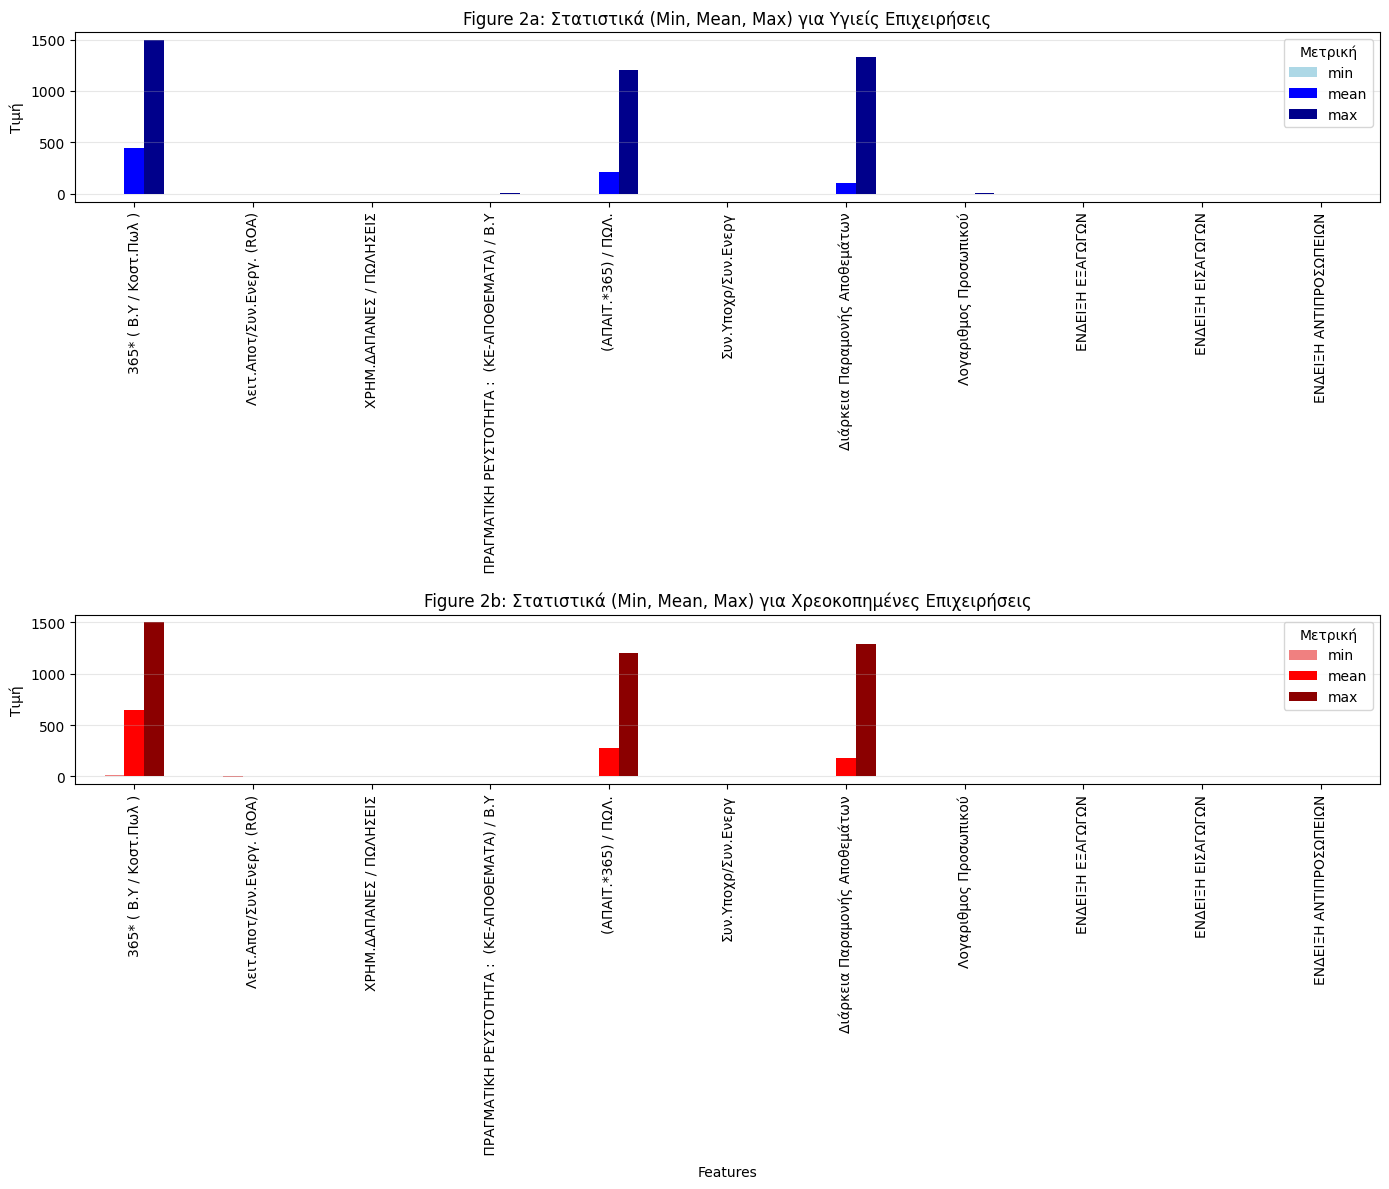

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Στήλες 0-10: Δεδομένα (Features)
# Στήλη 11: Status (1=Υγιής, 2=Χρεωκοπία)
# Στήλη 12: Year

# Δημιουργία ενός αντιγράφου για τα γραφήματα
df_plot = df.copy()

# Μετονομάζουμε τη στήλη Status για να φαίνεται ωραία στο γράφημα
# Η στήλη 11 είναι το Status. Την κάνουμε map: 1->Υγιής, 2->Χρεοκοπημένη
status_col_name = df.columns[11]
year_col_name = df.columns[12]

# Προσθέτουμε μια στήλη 'Κατάσταση' με λέξεις
df_plot['Κατάσταση'] = df_plot[status_col_name].map({1: 'Υγιής', 2: 'Χρεοκοπημένη'})

# --- FIGURE 1: Αριθμός υγιών και χρεωκοπημένων ανά έτος ---
plt.figure(figsize=(12, 6))
sns.countplot(data=df_plot, x=year_col_name, hue='Κατάσταση', palette={'Υγιής': 'green', 'Χρεοκοπημένη': 'red'})
plt.title('Figure 1: Πλήθος υγιών vs Χρεοκοπημένων Εταιρειών ανά έτος')
plt.xlabel('Έτος')
plt.ylabel('Πλήθος')
plt.legend(title='Κατάσταση εταιρείας')
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- FIGURE 2: Min, Max, Average για κάθε δείκτη (Subplots) ---
# Παίρνουμε μόνο τις στήλες με τα χαρακτηριστικά (0 έως 10)
feature_cols = df.columns[0:11]

# Χωρίζουμε τα δεδομένα σε Υγιείς και Χρεωκοπημένες
healthy_stats = df[df.iloc[:, 11] == 1][feature_cols].agg(['min', 'mean', 'max']).T
bankrupt_stats = df[df.iloc[:, 11] == 2][feature_cols].agg(['min', 'mean', 'max']).T

# Δημιουργία του γραφήματος (2 υπο-γραφήματα)
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Subplot 1: Υγιής
healthy_stats.plot(kind='bar', ax=axes[0], color=['lightblue', 'blue', 'darkblue'])
axes[0].set_title('Figure 2a: Στατιστικά (Min, Mean, Max) για Υγιείς Επιχειρήσεις')
axes[0].set_ylabel('Τιμή')
axes[0].legend(title='Μετρική')
axes[0].grid(axis='y', alpha=0.3)

# Subplot 2: Χρεοκοπημένη
bankrupt_stats.plot(kind='bar', ax=axes[1], color=['lightcoral', 'red', 'darkred'])
axes[1].set_title('Figure 2b: Στατιστικά (Min, Mean, Max) για Χρεοκοπημένες Επιχειρήσεις')
axes[1].set_ylabel('Τιμή')
axes[1].set_xlabel('Features')
axes[1].legend(title='Μετρική')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Βήμα 3ο**: Έλεγχος ελλειπών τιμών

In [3]:
print("--- ΕΛΕΓΧΟΣ ΓΙΑ ΕΛΛΕΙΠΕΙΣ ΤΙΜΕΣ (NaNs) ---")

# Ελέγχουμε πόσα κενά υπάρχουν σε κάθε στήλη
nan_count = df.isnull().sum()

# Ελέγχουμε αν υπάρχει έστω και ένα κενό συνολικά
if df.isnull().values.any():
    print("Βρέθηκαν ελλείπεις τιμές")
    print("\nΠλήθος κενών ανά στήλη:")
    print(nan_count[nan_count > 0]) # Τυπώνει μόνο τις στήλες που έχουν πρόβλημα

    # Κρατάμε το αρχικό πλήθος γραμμών
    rows_before = df.shape[0]
    # Το df.shape[0] αντιπροσωπεύει το πλήθος των γραμμών(εταιρειών)

    # ΔΙΑΓΡΑΦΗ: Πετάμε τις γραμμές που έχουν έστω και ένα NaN
    df = df.dropna()

    rows_after = df.shape[0]
    deleted_rows = rows_before - rows_after

    print(f"\nΔιαγράφηκαν {deleted_rows} γραμμές που περιείχαν NaNs.")
    print(f"Νέο πλήθος εταιρειών: {rows_after}")
else:
    print("Δεν βρέθηκαν ελλείπεις τιμές.")

# Επιβεβαίωση τελικού σχήματος
print(f"\nΤρέχον μέγεθος Dataset: {df.shape}")

--- ΕΛΕΓΧΟΣ ΓΙΑ ΕΛΛΕΙΠΕΙΣ ΤΙΜΕΣ (NaNs) ---
Δεν βρέθηκαν ελλείπεις τιμές.

Τρέχον μέγεθος Dataset: (10716, 13)


**Βήμα 4ο**: Κανονικοποίηση δεδομένων

In [4]:
from sklearn.preprocessing import MinMaxScaler

"""
Επειδή αργότερα θα πρέπει να γίνουν υπολογισμοί μετρικών
θα γίνουν μερικές αλλαγές στα δεδομένα. Η υγιής επιχείρηση
θα αντιπροσωπεύεται από το 0(από το 1 που είναι τώρα), ενώ
η χρεοκοπημένη θα αντιπροσωπεύεται από το 1(από το 2 που
είναι τώρα)
"""

# --- A. ΑΛΛΑΓΗ ΤΩΝ LABELS (0 και 1) ---
status_col = df.columns[11]

# Κάνουμε map: Το 1 γίνεται 0 (Υγιής), το 2 γίνεται 1 (Χρεοκοπημένη)
df[status_col] = df[status_col].map({1: 0, 2: 1})

print(f"Η στήλη '{status_col}' μετατράπηκε σε 0 (Υγιής) και 1 (Χρεοκοπημένη).")

# --- B. KANONIKOΠΟΙΗΣΗ (NORMALIZATION) ---
# Επιλέγουμε μόνο τις στήλες με τα χαρακτηριστικά (0 έως 10)
feature_cols = df.columns[0:11]

scaler = MinMaxScaler()
"""
Ο MinMaxScaler είναι ένας μετασχηματιστής που κανονικοποιεί
τα δεδομένα μεταξύ 0 και 1. Χρησιμοποιείται για να μην θεωρηθούν
κάποιες στήλες με δεδομένα πιο σημαντικές από κάποιες άλλες όταν
χρησιμοποιούνται αλγόριθμοι όπως ο K-Nearest Neighbors
"""

# Εφαρμόζουμε την κανονικοποίηση και αντικαθιστούμε τις τιμές στο dataframe
df[feature_cols] = scaler.fit_transform(df[feature_cols])

print("Η κανονικοποίηση ολοκληρώθηκε.")

# --- C. ΕΠΑΛΗΘΕΥΣΗ ---
print("\n--- Επαλήθευση (Min/Max πρέπει να είναι 0 και 1) ---")
print(df[feature_cols].describe().loc[['min', 'max']])

Η στήλη 'ΕΝΔΕΙΞΗ ΑΣΥΝΕΠΕΙΑΣ (=2) (ν+1)' μετατράπηκε σε 0 (Υγιής) και 1 (Χρεοκοπημένη).
Η κανονικοποίηση ολοκληρώθηκε.

--- Επαλήθευση (Min/Max πρέπει να είναι 0 και 1) ---
     365* ( Β.Υ / Κοστ.Πωλ )  Λειτ.Αποτ/Συν.Ενεργ. (ROA)  \
min                      0.0                         0.0   
max                      1.0                         1.0   

     ΧΡΗΜ.ΔΑΠΑΝΕΣ / ΠΩΛΗΣΕΙΣ   ΠΡΑΓΜΑΤΙΚΗ ΡΕΥΣΤΟΤΗΤΑ :  (ΚΕ-ΑΠΟΘΕΜΑΤΑ) / Β.Υ  \
min                      0.0                                             0.0   
max                      1.0                                             1.0   

     (ΑΠΑΙΤ.*365) / ΠΩΛ.  Συν.Υποχρ/Συν.Ενεργ  Διάρκεια Παραμονής Αποθεμάτων  \
min                  0.0                  0.0                            0.0   
max                  1.0                  1.0                            1.0   

     Λογαριθμος Προσωπικού  ΕΝΔΕΙΞΗ ΕΞΑΓΩΓΩΝ  ΕΝΔΕΙΞΗ ΕΙΣΑΓΩΓΩΝ  \
min                    0.0               0.0                0.0   
max                    1.0     

**Βήμα 5ο**: Δημιουργία Stratified K-fold

In [5]:
from sklearn.model_selection import StratifiedKFold

# Προετοιμασία πινάκων
# Ορίζουμε τα X (χαρακτηριστικά) και y (στόχος)
# Στήλες 0-10 είναι τα features
X = df[df.columns[0:11]].values
# Στήλη 11 είναι το status (0 ή 1)
y = df[df.columns[11]].values

# 5. Δημιουργία Stratified K-Fold (4 folds)
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
"""
Χωρίζουμε σε 4 κομμάτια. Κάνουμε την εκπαίδευση 4 φορές. Κάθε
φορά το train set παίρνει τα 3 κομμάτια και το test set μόνο το 1.
Οι χρεωκοπίες είναι σπάνιες. Συνεπώς, φροντίζουμε κάθε κομμάτι να
έχει το ίδιο ποσοστό χρεωκοπιών με το αρχικό dataset.
"""

print(f"Συνολικό Dataset: {len(y)} εταιρείες.")
print(f"Σύνολο Υγιών (Class 0): {sum(y == 0)}")
print(f"Σύνολο Χρεωκοπημένων (Class 1): {sum(y == 1)}")

Συνολικό Dataset: 10716 εταιρείες.
Σύνολο Υγιών (Class 0): 10468
Σύνολο Χρεωκοπημένων (Class 1): 248


**Βήμα 6ο**: Εκτύπωση υγιών και χρεοκοπημένων εταιρειών ανά fold

In [6]:
import numpy as np

# Εδώ θα αποθηκεύσουμε τα δεδομένα κάθε fold για να τα έχουμε έτοιμα για τα μοντέλα
folds_data = []

fold_no = 1

# Ξεκινάει το Loop για τα 4 folds
for train_index, test_index in skf.split(X, y):
    print(f"\n=== FOLD {fold_no} ===")

    # Χωρίζουμε σε Train και Test βάσει των δεικτών που έδωσε το KFold
    X_train_orig, X_test = X[train_index], X[test_index]
    y_train_orig, y_test = y[train_index], y[test_index]

    # Εκτύπωση κατανομών
    n_bankrupt_train = sum(y_train_orig == 1)
    n_healthy_train = sum(y_train_orig == 0)
    print(f"Σύνολο Εκπαίδευσης: Χρεοκοπημένες={n_bankrupt_train}, Υγιείς={n_healthy_train} (Σύνολο: {len(y_train_orig)})")
    print(f"Σύνολο Ελέγχου: Χρεοκοπημένες={sum(y_test == 1)}, Υγιείς={sum(y_test == 0)} (Σύνολο: {len(y_test)})")

    # 7. Υποδειγματοληψία (Undersampling) στο Train Set
    # Στόχος: 3 Υγιείς για κάθε 1 Χρεωκοπημένη

    # Βρίσκουμε τις θέσεις (indices) των υγιών και των χρεωκοπημένων στο X_train_orig
    ind_bankrupt = np.where(y_train_orig == 1)[0]
    ind_healthy = np.where(y_train_orig == 0)[0]

    # Κρατάμε 3 * αριθμός χρεωκοπημένων
    n_healthy_to_keep = n_bankrupt_train * 3

    ind_healthy_downsampled = np.random.choice(ind_healthy, size=n_healthy_to_keep, replace=False)
    # replace=False σημαίνει ότι η ίδια εταιρεία δεν διαλέγεται 2 φορές
    """
    Από την λίστα ind_healthy που περιέχει υγιείς εταιρείες
    διαλέγουμε σε πλήθος = n_healthy_to_keep όπου είναι ο τριπλάσιος
    αριθμός από τις χρεωκοπημένες
    """

    # Ενώνουμε τους δείκτες (όλους τους χρεωκοπημένους + τους λίγους υγιείς)
    final_indices = np.concatenate([ind_bankrupt, ind_healthy_downsampled])

    # Ανακατεύουμε πάλι για να μην είναι πρώτα όλοι οι χρεωκοπημένοι και μετά οι υγιείς
    np.random.shuffle(final_indices)
    # Αλλάζει η σειρά αλλά όχι το περιεχόμενο, ώστε το μοντέλο να μην μάθει λάθος σειρά

    # Δημιουργούμε τα νέα balanced Train Sets
    X_train_balanced = X_train_orig[final_indices]
    y_train_balanced = y_train_orig[final_indices]

    print(f"-> BALANCED Train: Χρεοκοπημένες={sum(y_train_balanced==1)}, Υγιείς={sum(y_train_balanced==0)} (Σύνολο: {len(y_train_balanced)})")
    print("   (Αναλογία ελέγχου: {:.1f} Υγιείς : 1 Χρεοκοπημένες)".format(sum(y_train_balanced==0)/sum(y_train_balanced==1)))

    # Αποθηκεύουμε τα έτοιμα δεδομένα στη λίστα για να τα χρησιμοποιήσουμε μετά
    folds_data.append({
        'X_train': X_train_balanced,
        'y_train': y_train_balanced,
        'X_test': X_test,
        'y_test': y_test,
        'fold_id': fold_no
    })

    fold_no += 1


=== FOLD 1 ===
Σύνολο Εκπαίδευσης: Χρεοκοπημένες=186, Υγιείς=7851 (Σύνολο: 8037)
Σύνολο Ελέγχου: Χρεοκοπημένες=62, Υγιείς=2617 (Σύνολο: 2679)
-> BALANCED Train: Χρεοκοπημένες=186, Υγιείς=558 (Σύνολο: 744)
   (Αναλογία ελέγχου: 3.0 Υγιείς : 1 Χρεοκοπημένες)

=== FOLD 2 ===
Σύνολο Εκπαίδευσης: Χρεοκοπημένες=186, Υγιείς=7851 (Σύνολο: 8037)
Σύνολο Ελέγχου: Χρεοκοπημένες=62, Υγιείς=2617 (Σύνολο: 2679)
-> BALANCED Train: Χρεοκοπημένες=186, Υγιείς=558 (Σύνολο: 744)
   (Αναλογία ελέγχου: 3.0 Υγιείς : 1 Χρεοκοπημένες)

=== FOLD 3 ===
Σύνολο Εκπαίδευσης: Χρεοκοπημένες=186, Υγιείς=7851 (Σύνολο: 8037)
Σύνολο Ελέγχου: Χρεοκοπημένες=62, Υγιείς=2617 (Σύνολο: 2679)
-> BALANCED Train: Χρεοκοπημένες=186, Υγιείς=558 (Σύνολο: 744)
   (Αναλογία ελέγχου: 3.0 Υγιείς : 1 Χρεοκοπημένες)

=== FOLD 4 ===
Σύνολο Εκπαίδευσης: Χρεοκοπημένες=186, Υγιείς=7851 (Σύνολο: 8037)
Σύνολο Ελέγχου: Χρεοκοπημένες=62, Υγιείς=2617 (Σύνολο: 2679)
-> BALANCED Train: Χρεοκοπημένες=186, Υγιείς=558 (Σύνολο: 744)
   (Αναλογία ελέγχου

**Βήμα 8ο**: Εκπαίδευση μοντέλων

Πρώτα, θα δημιουργήσουμε μία λίστα με τα μοντέλα

In [7]:
# --- IMPORTS ---
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Εισάγουμε τις μετρικές αξιολόγησης
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay

# --- ΟΡΙΣΜΟΣ ΜΟΝΤΕΛΩΝ ---

models_list = [
    ('LDA', LinearDiscriminantAnalysis()),

    # Logistic Regression: max_iter=1000
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),

    # Decision Tree: max_depth=5
    ('Decision Tree', DecisionTreeClassifier(max_depth=5, random_state=42)),

    # Random Forest: n_estimators=100 (100 δέντρα)
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),

    # KNN: n_neighbors=5 (κοιτάει τους 5 κοντινότερους)
    ('KNN', KNeighborsClassifier(n_neighbors=5)),

    ('Naive Bayes', GaussianNB()),

    # SVM: probability=True
    ('SVM', SVC(probability=True, random_state=42)),

    # Gradient Boosting: learning_rate=0.1 (πόσο γρήγορα μαθαίνει)
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
]

print("Τα μοντέλα ορίστηκαν επιτυχώς!")
print(f"Έχουμε συνολικά {len(models_list)} μοντέλα έτοιμα για εκπαίδευση.")

Τα μοντέλα ορίστηκαν επιτυχώς!
Έχουμε συνολικά 8 μοντέλα έτοιμα για εκπαίδευση.


Το μεγάλο loop. Εδώ θα εκπαιδευτούν όλα τα μοντέλα

Created directory: plots/
Ξεκινάει η εκπαίδευση και αξιολόγηση των μοντέλων...


==================== FOLD 1 ====================
--> Εκπαίδευση: LDA...
    [Test Set] Acc: 0.93 | Recall: 0.42 | Precision: 0.14 | F1: 0.21 | AUC: 0.83
    Saved plot: plots/fold_1_LDA_confusion_matrices.png


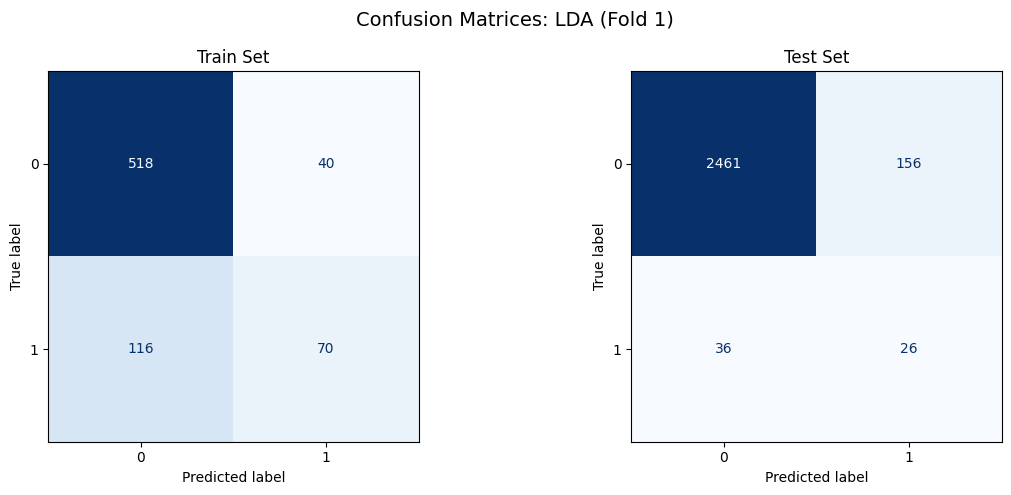

--> Εκπαίδευση: Logistic Regression...
    [Test Set] Acc: 0.94 | Recall: 0.42 | Precision: 0.16 | F1: 0.24 | AUC: 0.84
    Saved plot: plots/fold_1_Logistic_Regression_confusion_matrices.png


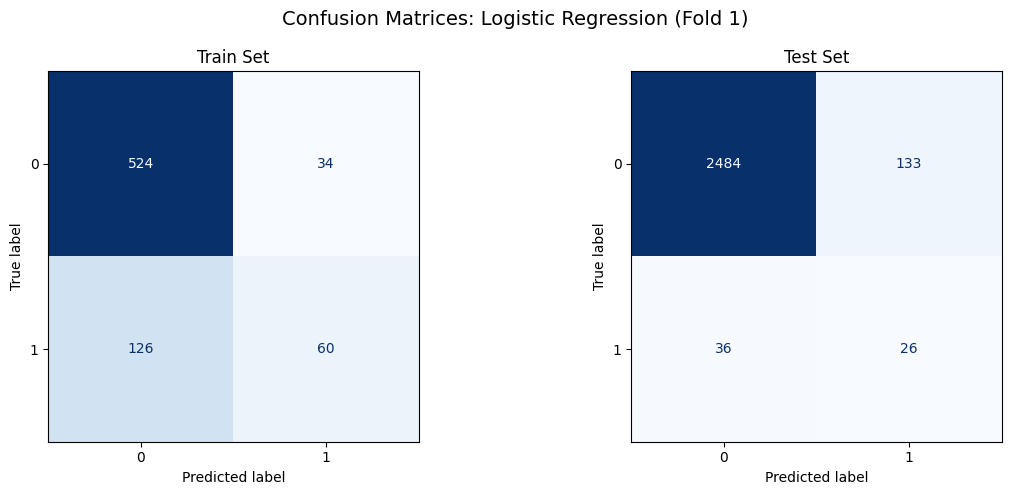

--> Εκπαίδευση: Decision Tree...
    [Test Set] Acc: 0.87 | Recall: 0.37 | Precision: 0.07 | F1: 0.11 | AUC: 0.72
    Saved plot: plots/fold_1_Decision_Tree_confusion_matrices.png


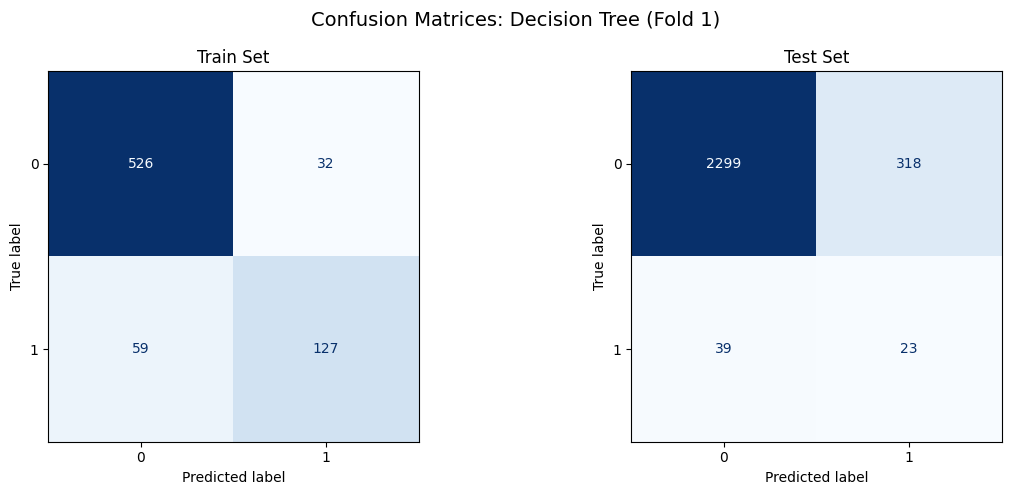

--> Εκπαίδευση: Random Forest...
    [Test Set] Acc: 0.92 | Recall: 0.42 | Precision: 0.13 | F1: 0.20 | AUC: 0.85
    Saved plot: plots/fold_1_Random_Forest_confusion_matrices.png


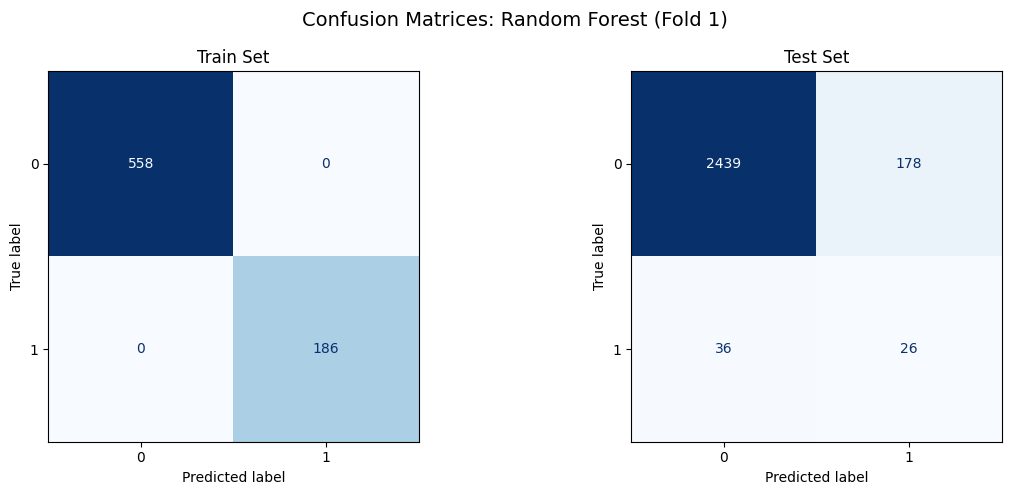

--> Εκπαίδευση: KNN...
    [Test Set] Acc: 0.89 | Recall: 0.55 | Precision: 0.12 | F1: 0.19 | AUC: 0.82
    Saved plot: plots/fold_1_KNN_confusion_matrices.png


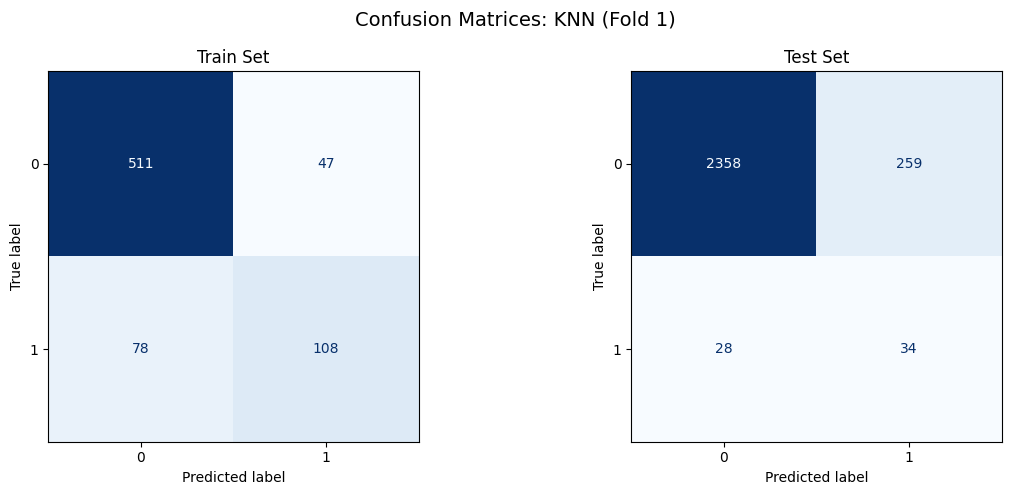

--> Εκπαίδευση: Naive Bayes...
    [Test Set] Acc: 0.89 | Recall: 0.50 | Precision: 0.11 | F1: 0.18 | AUC: 0.83
    Saved plot: plots/fold_1_Naive_Bayes_confusion_matrices.png


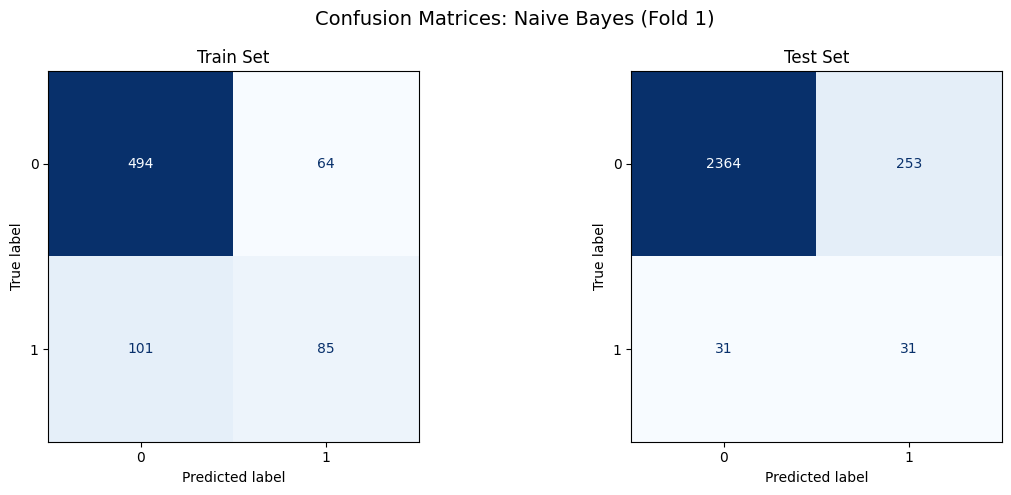

--> Εκπαίδευση: SVM...
    [Test Set] Acc: 0.94 | Recall: 0.42 | Precision: 0.18 | F1: 0.25 | AUC: 0.84
    Saved plot: plots/fold_1_SVM_confusion_matrices.png


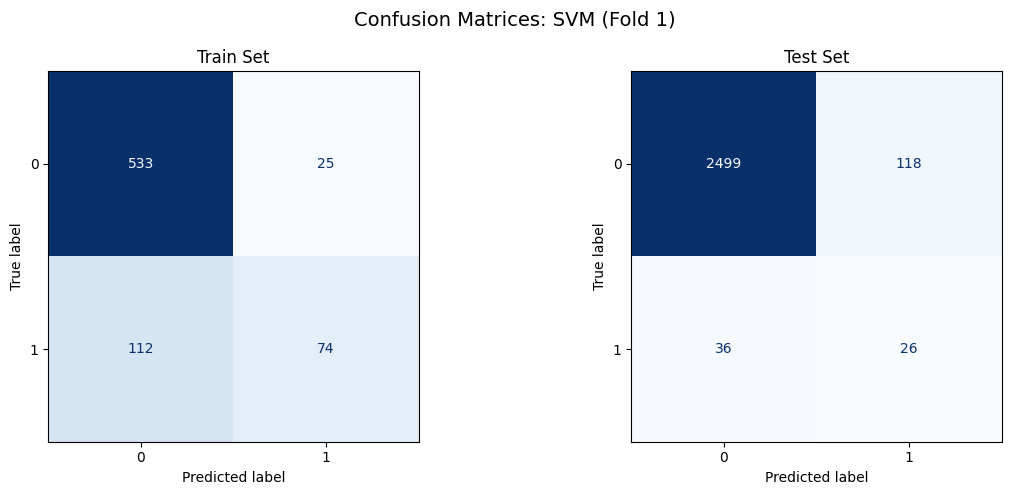

--> Εκπαίδευση: Gradient Boosting...
    [Test Set] Acc: 0.90 | Recall: 0.47 | Precision: 0.11 | F1: 0.18 | AUC: 0.82
    Saved plot: plots/fold_1_Gradient_Boosting_confusion_matrices.png


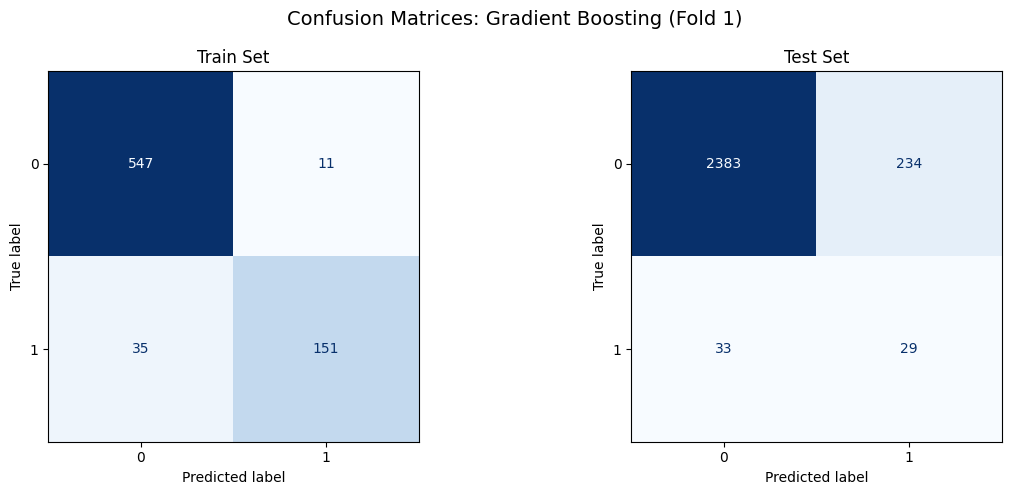


==================== FOLD 2 ====================
--> Εκπαίδευση: LDA...
    [Test Set] Acc: 0.91 | Recall: 0.48 | Precision: 0.12 | F1: 0.19 | AUC: 0.86
    Saved plot: plots/fold_2_LDA_confusion_matrices.png


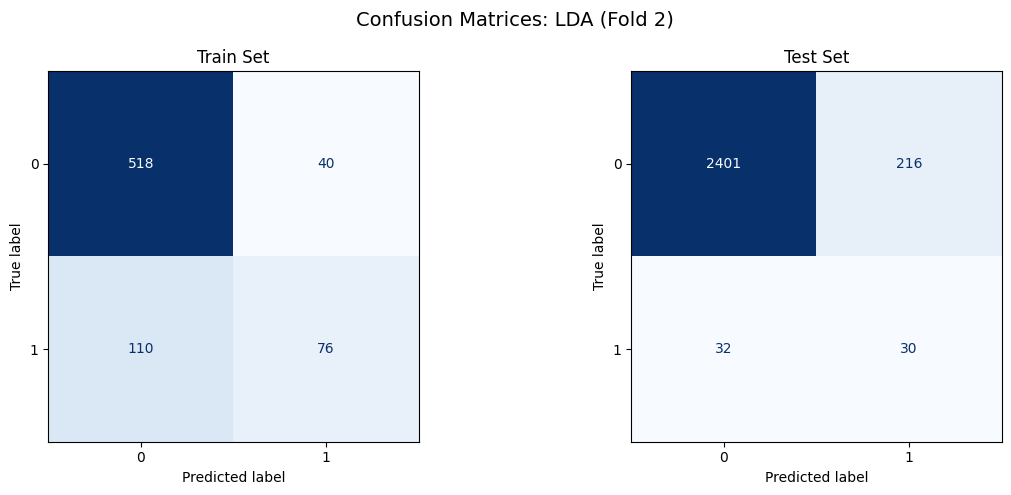

--> Εκπαίδευση: Logistic Regression...
    [Test Set] Acc: 0.93 | Recall: 0.44 | Precision: 0.15 | F1: 0.22 | AUC: 0.86
    Saved plot: plots/fold_2_Logistic_Regression_confusion_matrices.png


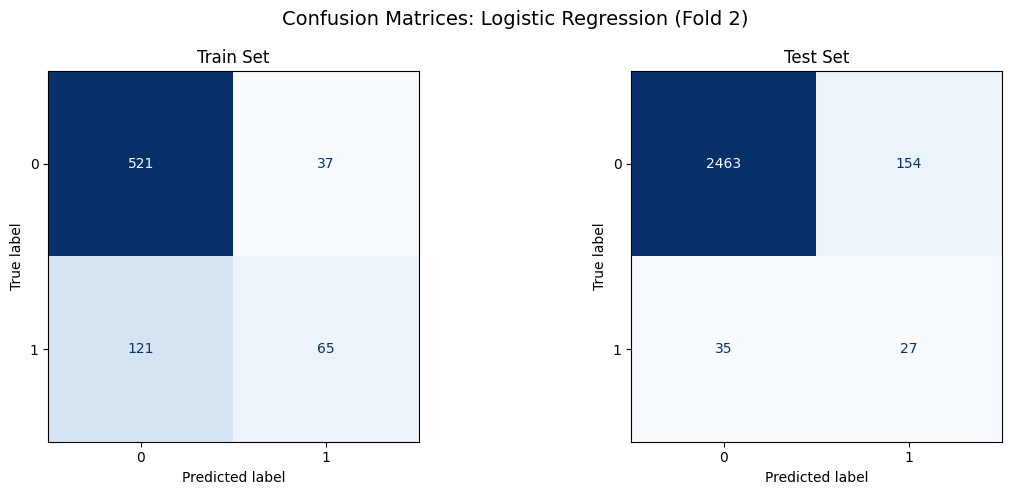

--> Εκπαίδευση: Decision Tree...
    [Test Set] Acc: 0.86 | Recall: 0.44 | Precision: 0.07 | F1: 0.13 | AUC: 0.75
    Saved plot: plots/fold_2_Decision_Tree_confusion_matrices.png


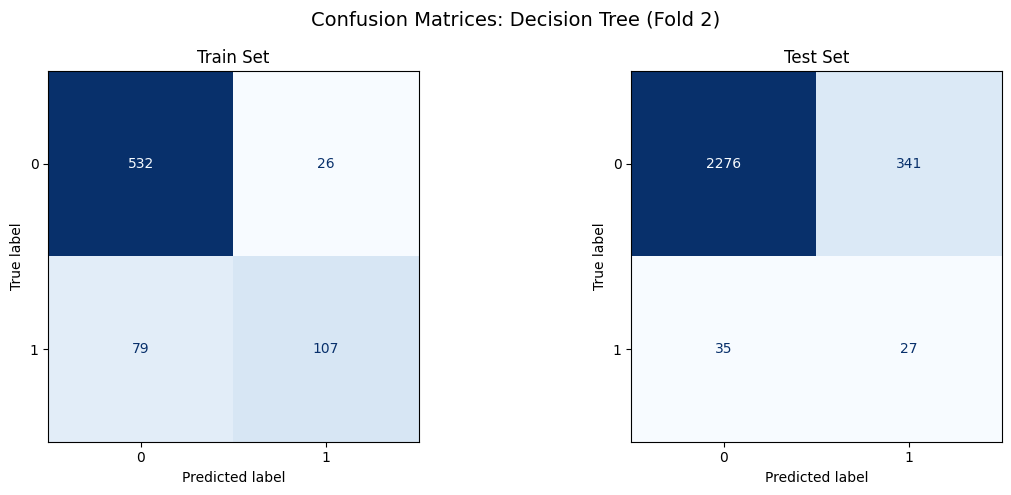

--> Εκπαίδευση: Random Forest...
    [Test Set] Acc: 0.91 | Recall: 0.60 | Precision: 0.15 | F1: 0.23 | AUC: 0.89
    Saved plot: plots/fold_2_Random_Forest_confusion_matrices.png


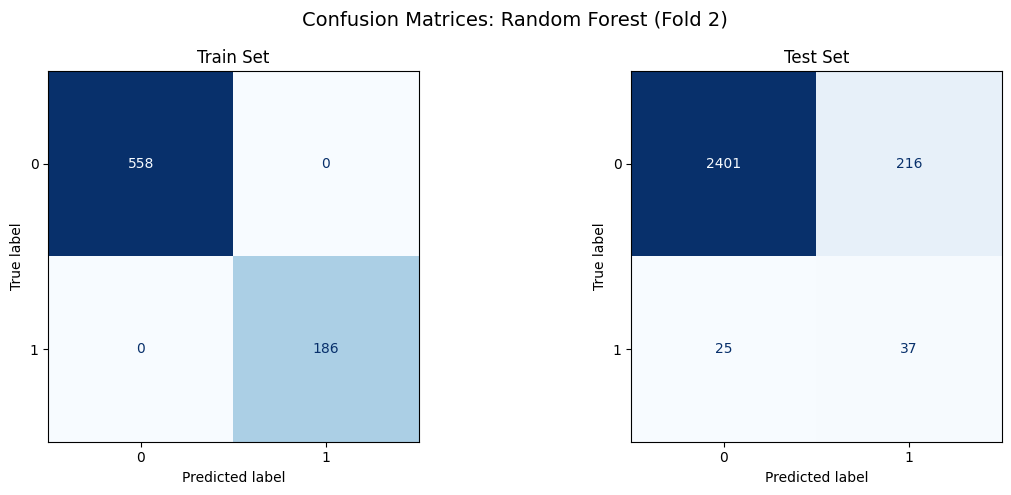

--> Εκπαίδευση: KNN...
    [Test Set] Acc: 0.88 | Recall: 0.52 | Precision: 0.10 | F1: 0.17 | AUC: 0.84
    Saved plot: plots/fold_2_KNN_confusion_matrices.png


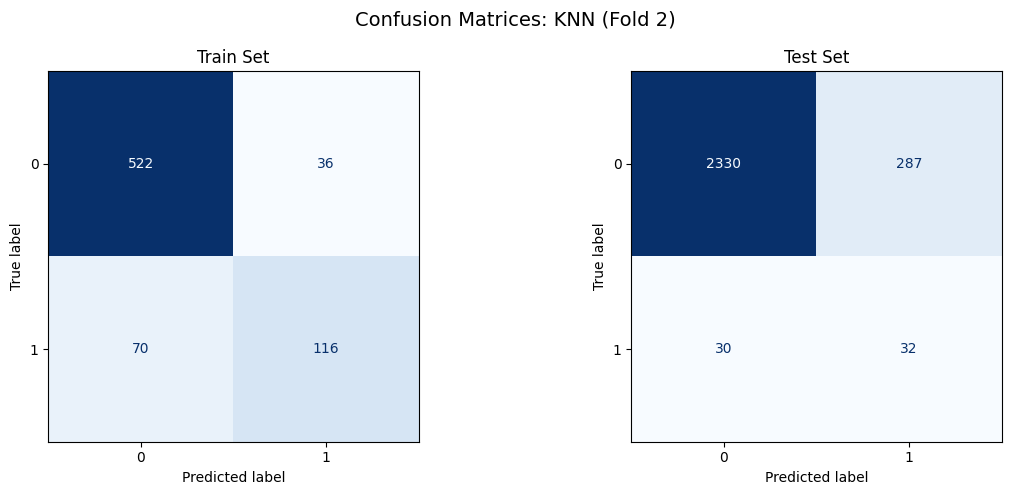

--> Εκπαίδευση: Naive Bayes...
    [Test Set] Acc: 0.87 | Recall: 0.61 | Precision: 0.10 | F1: 0.17 | AUC: 0.83
    Saved plot: plots/fold_2_Naive_Bayes_confusion_matrices.png


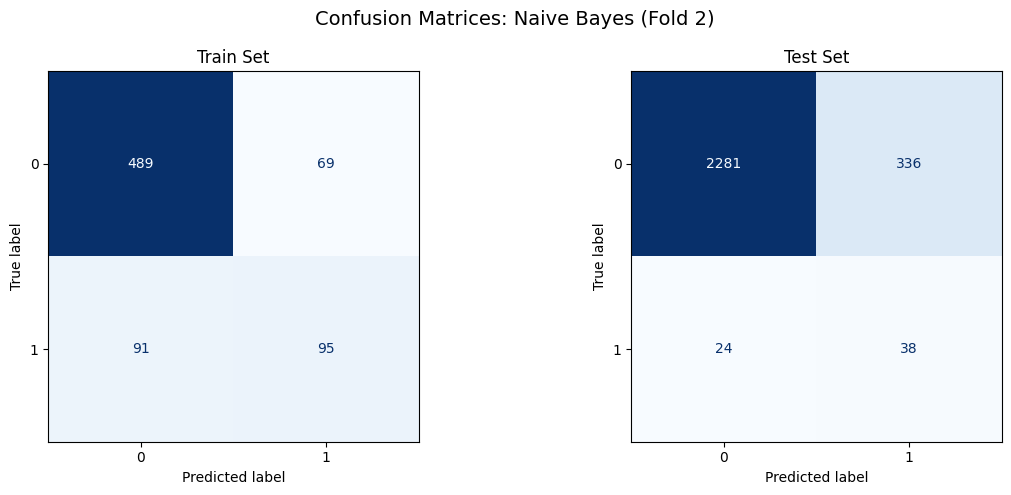

--> Εκπαίδευση: SVM...
    [Test Set] Acc: 0.93 | Recall: 0.52 | Precision: 0.17 | F1: 0.26 | AUC: 0.84
    Saved plot: plots/fold_2_SVM_confusion_matrices.png


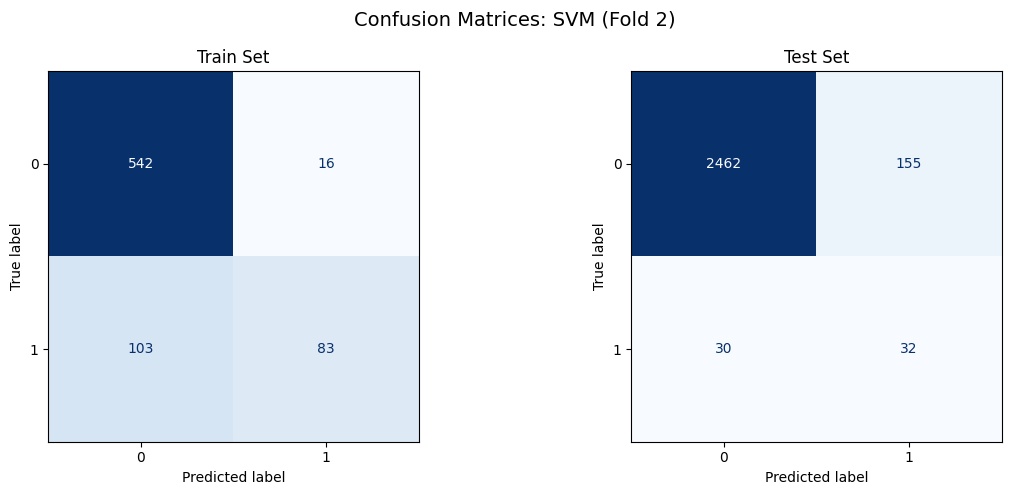

--> Εκπαίδευση: Gradient Boosting...
    [Test Set] Acc: 0.90 | Recall: 0.55 | Precision: 0.12 | F1: 0.20 | AUC: 0.86
    Saved plot: plots/fold_2_Gradient_Boosting_confusion_matrices.png


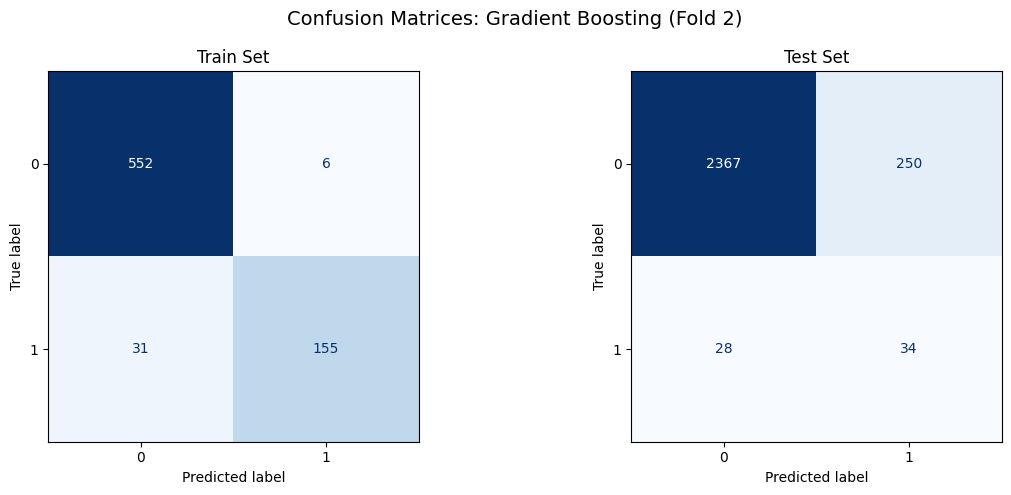


==================== FOLD 3 ====================
--> Εκπαίδευση: LDA...
    [Test Set] Acc: 0.91 | Recall: 0.32 | Precision: 0.09 | F1: 0.14 | AUC: 0.80
    Saved plot: plots/fold_3_LDA_confusion_matrices.png


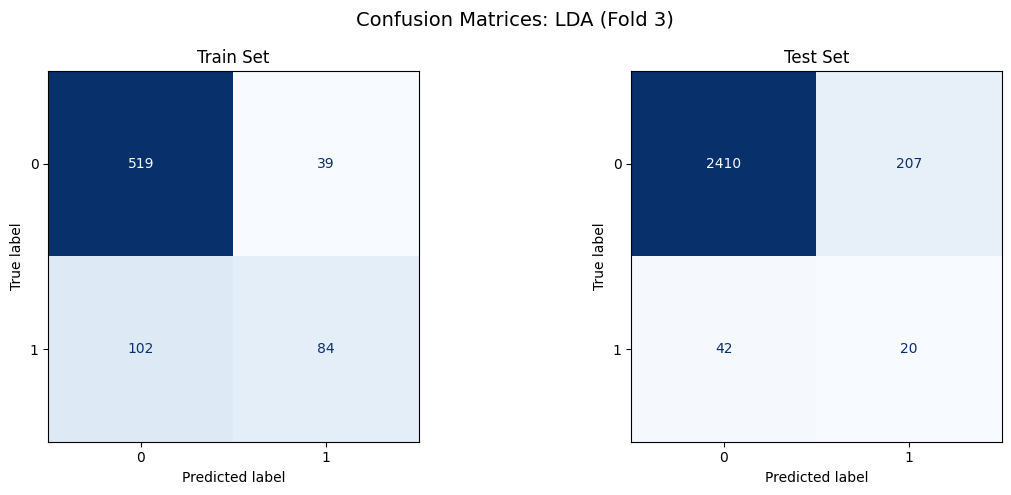

--> Εκπαίδευση: Logistic Regression...
    [Test Set] Acc: 0.92 | Recall: 0.26 | Precision: 0.08 | F1: 0.12 | AUC: 0.79
    Saved plot: plots/fold_3_Logistic_Regression_confusion_matrices.png


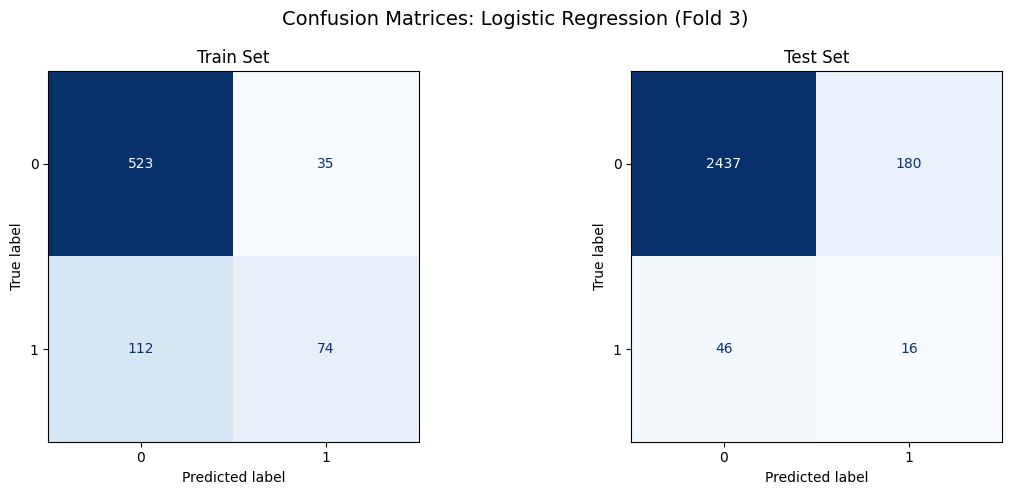

--> Εκπαίδευση: Decision Tree...
    [Test Set] Acc: 0.86 | Recall: 0.44 | Precision: 0.07 | F1: 0.13 | AUC: 0.71
    Saved plot: plots/fold_3_Decision_Tree_confusion_matrices.png


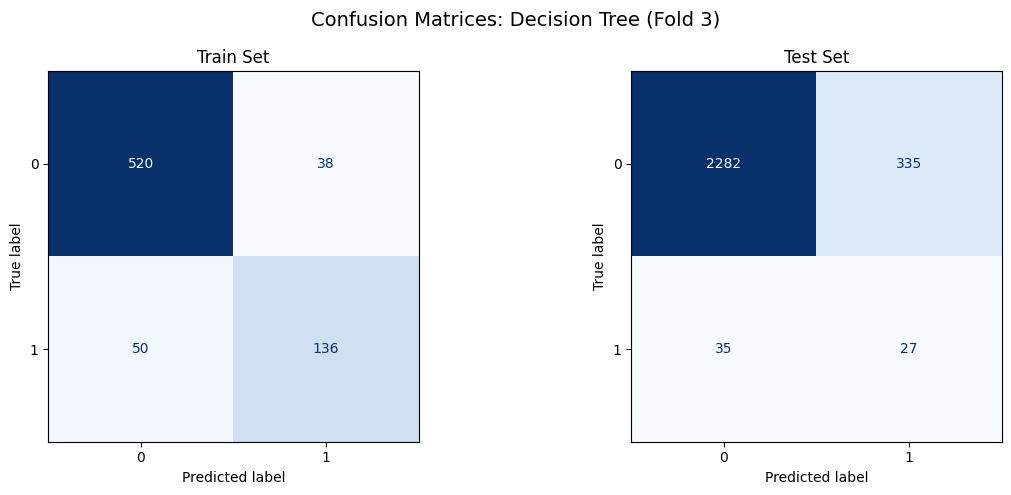

--> Εκπαίδευση: Random Forest...
    [Test Set] Acc: 0.90 | Recall: 0.37 | Precision: 0.10 | F1: 0.15 | AUC: 0.78
    Saved plot: plots/fold_3_Random_Forest_confusion_matrices.png


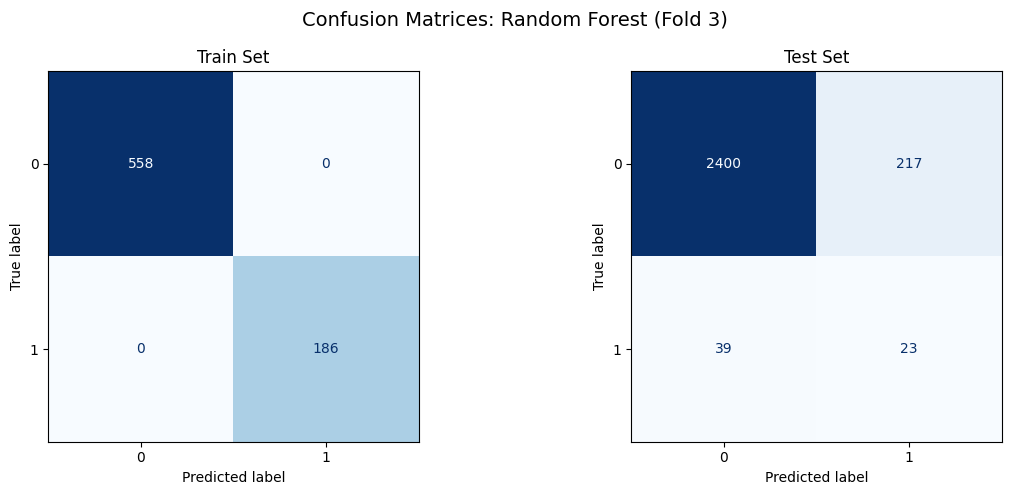

--> Εκπαίδευση: KNN...
    [Test Set] Acc: 0.88 | Recall: 0.31 | Precision: 0.06 | F1: 0.11 | AUC: 0.73
    Saved plot: plots/fold_3_KNN_confusion_matrices.png


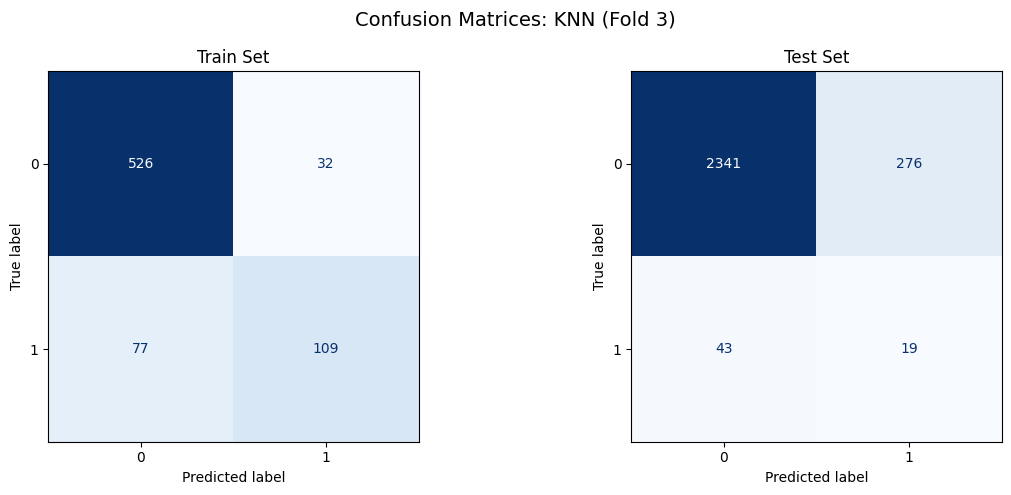

--> Εκπαίδευση: Naive Bayes...
    [Test Set] Acc: 0.86 | Recall: 0.39 | Precision: 0.07 | F1: 0.11 | AUC: 0.78
    Saved plot: plots/fold_3_Naive_Bayes_confusion_matrices.png


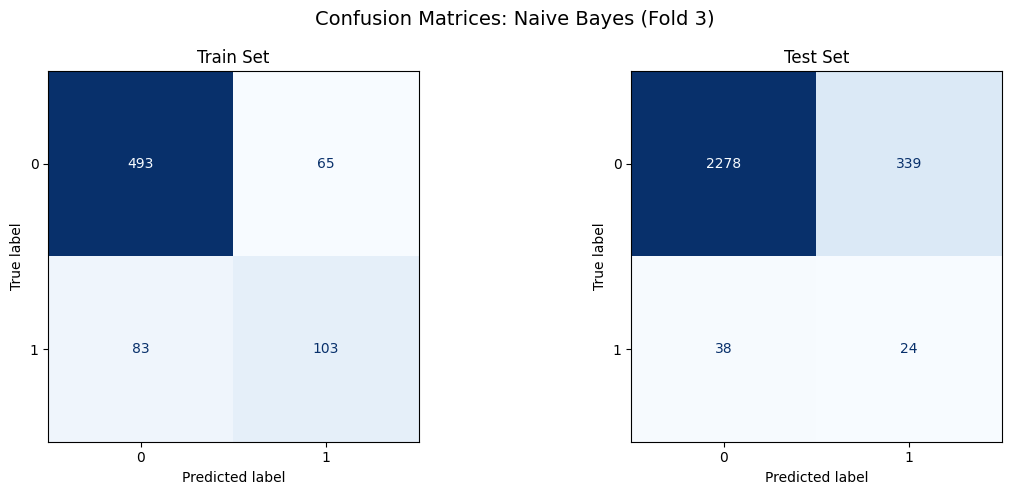

--> Εκπαίδευση: SVM...
    [Test Set] Acc: 0.92 | Recall: 0.27 | Precision: 0.09 | F1: 0.13 | AUC: 0.79
    Saved plot: plots/fold_3_SVM_confusion_matrices.png


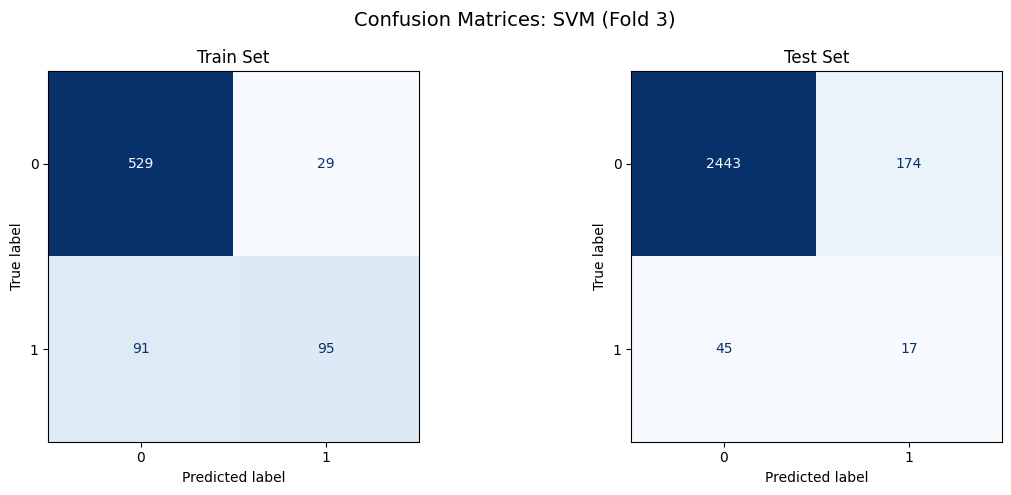

--> Εκπαίδευση: Gradient Boosting...
    [Test Set] Acc: 0.90 | Recall: 0.35 | Precision: 0.09 | F1: 0.14 | AUC: 0.79
    Saved plot: plots/fold_3_Gradient_Boosting_confusion_matrices.png


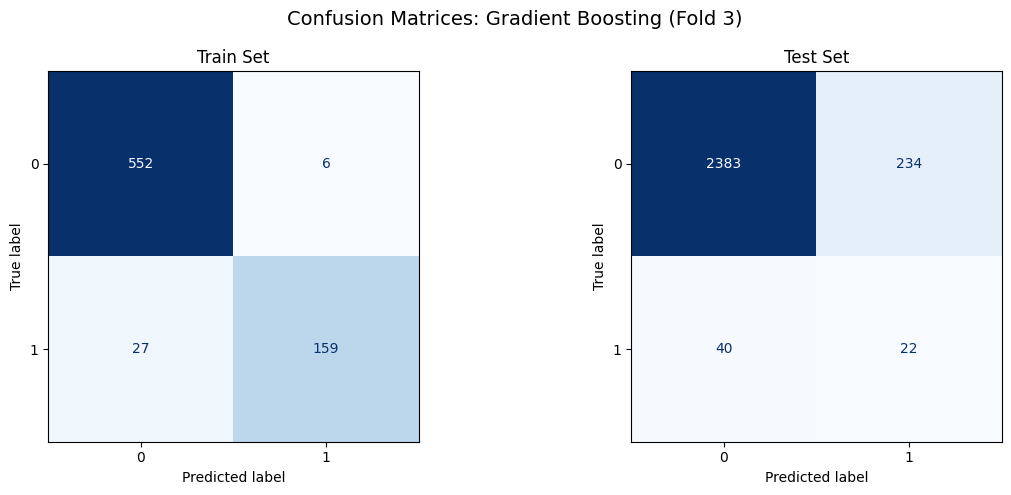


==================== FOLD 4 ====================
--> Εκπαίδευση: LDA...
    [Test Set] Acc: 0.91 | Recall: 0.35 | Precision: 0.10 | F1: 0.16 | AUC: 0.85
    Saved plot: plots/fold_4_LDA_confusion_matrices.png


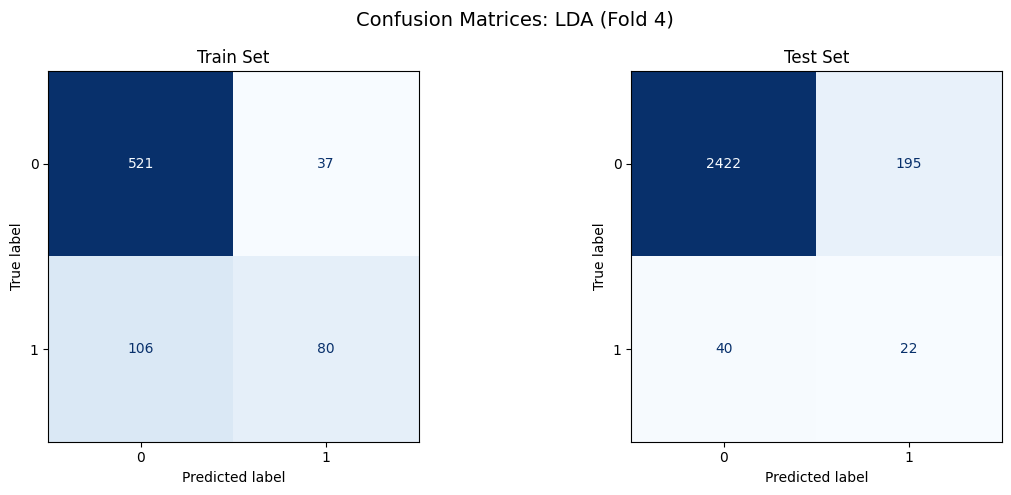

--> Εκπαίδευση: Logistic Regression...
    [Test Set] Acc: 0.92 | Recall: 0.34 | Precision: 0.11 | F1: 0.16 | AUC: 0.84
    Saved plot: plots/fold_4_Logistic_Regression_confusion_matrices.png


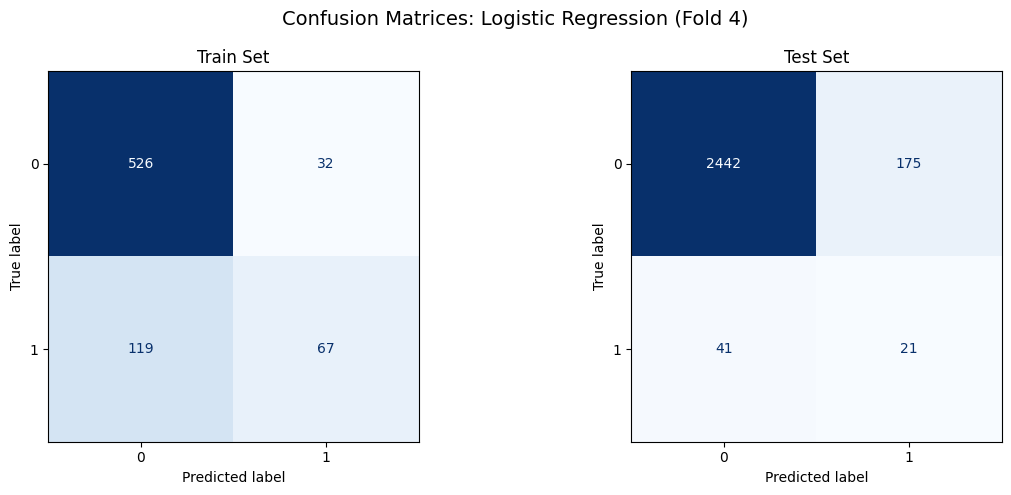

--> Εκπαίδευση: Decision Tree...
    [Test Set] Acc: 0.89 | Recall: 0.40 | Precision: 0.09 | F1: 0.15 | AUC: 0.77
    Saved plot: plots/fold_4_Decision_Tree_confusion_matrices.png


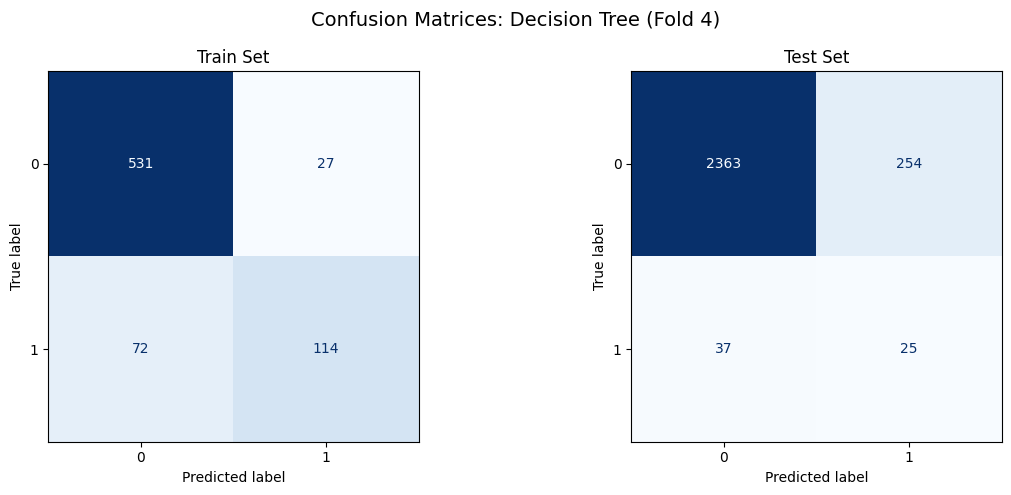

--> Εκπαίδευση: Random Forest...
    [Test Set] Acc: 0.92 | Recall: 0.45 | Precision: 0.14 | F1: 0.21 | AUC: 0.84
    Saved plot: plots/fold_4_Random_Forest_confusion_matrices.png


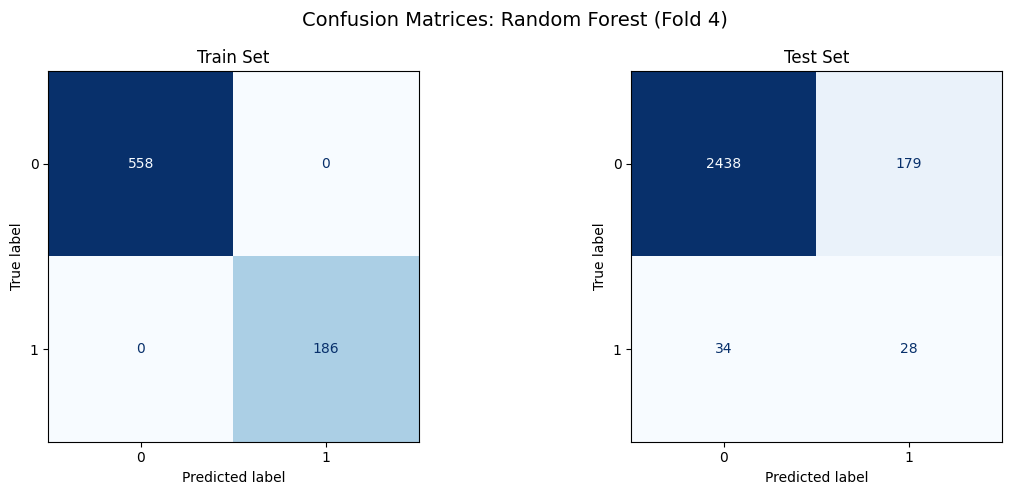

--> Εκπαίδευση: KNN...
    [Test Set] Acc: 0.88 | Recall: 0.37 | Precision: 0.07 | F1: 0.12 | AUC: 0.80
    Saved plot: plots/fold_4_KNN_confusion_matrices.png


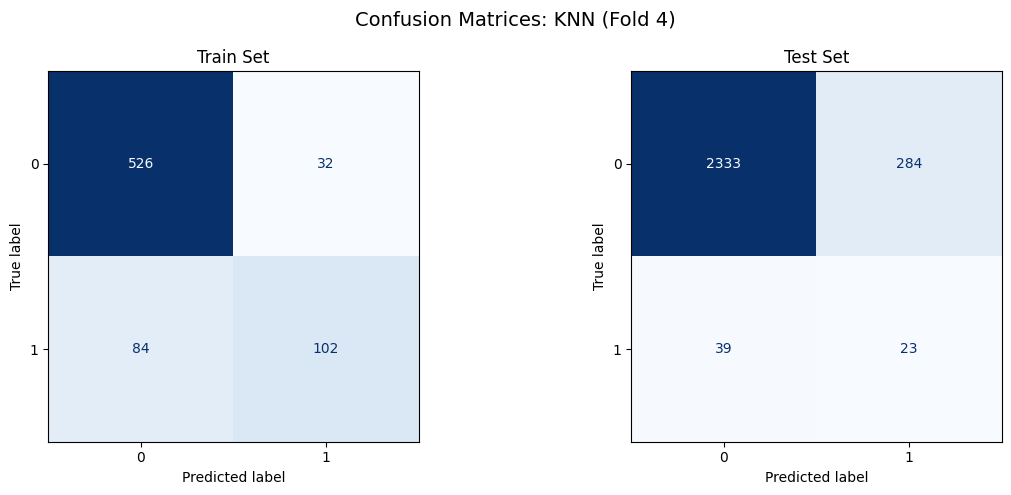

--> Εκπαίδευση: Naive Bayes...
    [Test Set] Acc: 0.87 | Recall: 0.48 | Precision: 0.08 | F1: 0.14 | AUC: 0.83
    Saved plot: plots/fold_4_Naive_Bayes_confusion_matrices.png


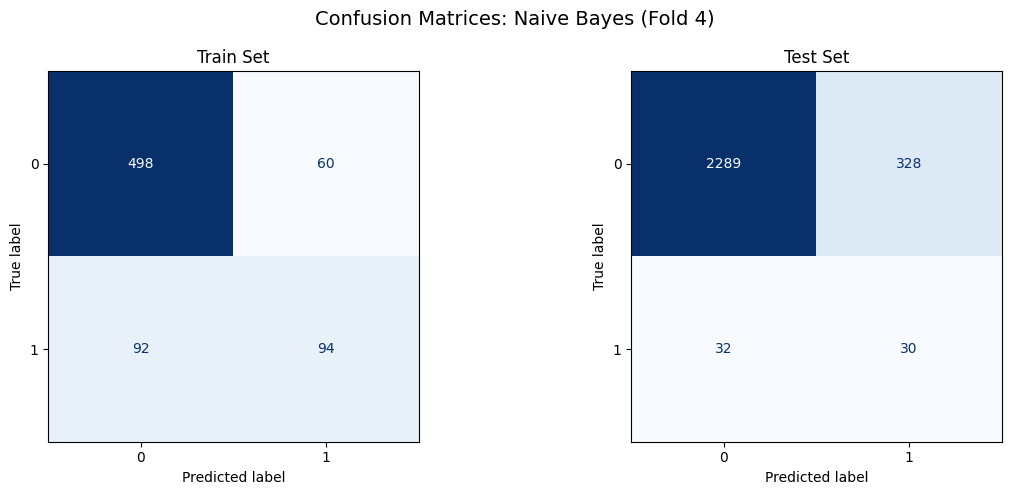

--> Εκπαίδευση: SVM...
    [Test Set] Acc: 0.93 | Recall: 0.34 | Precision: 0.12 | F1: 0.18 | AUC: 0.82
    Saved plot: plots/fold_4_SVM_confusion_matrices.png


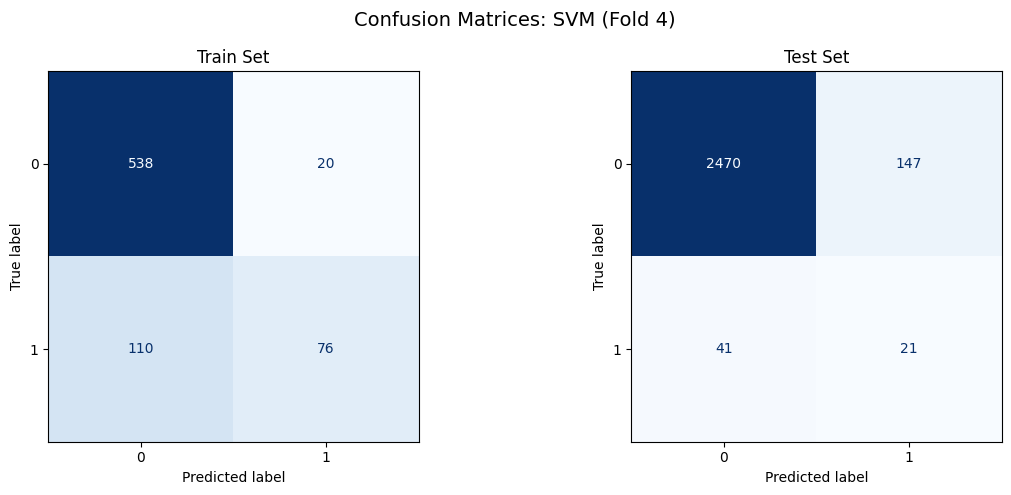

--> Εκπαίδευση: Gradient Boosting...
    [Test Set] Acc: 0.91 | Recall: 0.50 | Precision: 0.12 | F1: 0.20 | AUC: 0.85
    Saved plot: plots/fold_4_Gradient_Boosting_confusion_matrices.png


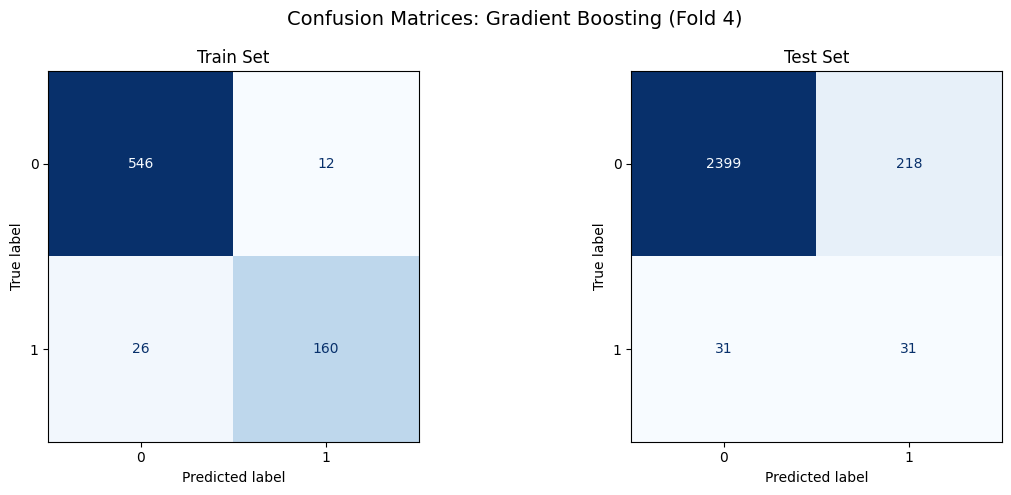


--- Η εκπαίδευση ολοκληρώθηκε! ---
Τα αποτελέσματα αποθηκεύτηκαν στο αρχείο: balancedDataOutcomes.csv


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd
import os

# Create a directory to save plots if it doesn't exist
plots_dir = 'plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)
    print(f"Created directory: {plots_dir}/")

# Λίστα για να μαζέψουμε τα δεδομένα για το Excel (Step 9d)
results_for_excel = []

print("Ξεκινάει η εκπαίδευση και αξιολόγηση των μοντέλων...\n")

# --- ΕΞΩΤΕΡΙΚΟΣ ΒΡΟΧΟΣ: FOLDS ---
for fold_info in folds_data:
    fold_id = fold_info['fold_id']
    X_train = fold_info['X_train']
    y_train = fold_info['y_train']
    X_test = fold_info['X_test']
    y_test = fold_info['y_test']

    print(f"\n{'='*20} FOLD {fold_id} {'='*20}")

    # --- ΕΣΩΤΕΡΙΚΟΣ ΒΡΟΧΟΣ: MODELS ---
    for model_name, model in models_list:
        print(f"--> Εκπαίδευση: {model_name}...")

        # 1. ΕΚΠΑΙΔΕΥΣΗ (FIT)
        # Κλωνοποιούμε το μοντέλο για να είναι καθαρό σε κάθε fold
        clf = model
        clf.fit(X_train, y_train)

        # 2. ΠΡΟΒΛΕΨΕΙΣ (PREDICT)
        # Πρόβλεψη στο Train
        y_train_pred = clf.predict(X_train)
        y_train_prob = clf.predict_proba(X_train)[:, 1] # Πιθανότητες για AUC

        # Πρόβλεψη στο Test
        y_test_pred = clf.predict(X_test)
        y_test_prob = clf.predict_proba(X_test)[:, 1]   # Πιθανότητες για AUC

        # 3. ΥΠΟΛΟΓΙΣΜΟΣ ΜΕΤΡΙΚΩΝ & CONFUSION MATRICES
        # Φτιάχνουμε μια λίστα με (Set Name, y_true, y_pred, y_prob, Balance_Type)
        datasets_eval = [
            ('Train', y_train, y_train_pred, y_train_prob, 'Balanced'),
            ('Test', y_test, y_test_pred, y_test_prob, 'Unbalanced')
        ]

        # Σχεδίαση γραφημάτων (Ζητούμενο 9a)
        # Φτιάχνουμε χώρο για 2 γραφήματα δίπλα-δίπλα (Train αριστερά, Test δεξιά)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'Confusion Matrices: {model_name} (Fold {fold_id})', fontsize=14)

        for idx, (set_name, y_true, y_pred, y_prob, balance_type) in enumerate(datasets_eval):
            # Υπολογισμός μετρικών
            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            auc = roc_auc_score(y_true, y_prob)

            # Confusion Matrix στοιχεία
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

            # Εκτύπωση στην οθόνη (Ζητούμενο 9c)
            if set_name == 'Test':
                print(f"    [Test Set] Acc: {acc:.2f} | Recall: {rec:.2f} | Precision: {prec:.2f} | F1: {f1:.2f} | AUC: {auc:.2f}")

            # Σχεδίαση Confusion Matrix στο αντίστοιχο subplot
            ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axes[idx], colorbar=False, cmap='Blues')
            axes[idx].set_title(f"{set_name} Set")

            # 4. ΑΠΟΘΗΚΕΥΣΗ ΣΤΟ DATAFRAME (Ζητούμενο 9d)
            results_for_excel.append({
                'Classifier Name': model_name,
                'Training or Test set': set_name,
                'Balanced or unbalanced train set': balance_type,
                'Number of training samples': len(y_true),
                'Number of non-healthy companies': sum(y_true == 1),
                'TP': tp,
                'TN': tn,
                'FP': fp,
                'FN': fn,
                'ROC-AUC': auc,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1 Score': f1,
                'Fold': fold_id
            })

        # Save the figure to the 'plots' directory
        # Sanitize model_name for filename
        safe_model_name = model_name.replace(' ', '_').replace('/', '_').replace(':', '_')
        plot_filename = os.path.join(plots_dir, f'fold_{fold_id}_{safe_model_name}_confusion_matrices.png')
        plt.savefig(plot_filename)
        print(f"    Saved plot: {plot_filename}")

        # Εμφάνιση των γραφημάτων
        plt.tight_layout()
        plt.show()

# --- ΒΗΜΑ 10: ΑΠΟΘΗΚΕΥΣΗ ΣΕ CSV ---
print("\n--- Η εκπαίδευση ολοκληρώθηκε! ---")
df_results = pd.DataFrame(results_for_excel)

filename = "balancedDataOutcomes.csv"
df_results.to_csv(filename, index=False)

print(f"Τα αποτελέσματα αποθηκεύτηκαν στο αρχείο: {filename}")